# Credit Card Fraud Detection & Analytics System
### Comprehensive Data Queries, Exploratory Data Analysis, Classification Pipeline, and Serialization

**Objective:**
Establish a highly rigorous credit card fraud detection system. This notebook walks through basic data query analysis, extensive visual analytics utilizing Matplotlib and Seaborn, strict train-test feature preprocessing splits, synthetic class-imbalance oversampling, model building, cost-sensitive model diagnostics, and model serialization.

**Core Project Structure:**
1. **Part 1: SQL-Style Pandas Data Queries** (aggregations, counts, sorts, and custom filters)
2. **Part 2: Visual EDA with Matplotlib** (Line, Bar, Horizontal Bar, Hist, Scatter, Pie, and Box Plots)
3. **Part 3: Visual EDA with Seaborn** (Countplot, Barplot, Histplot, KDEPlot, Boxplot, Violinplot, Jointplot, and Pairplot)
4. **Part 4: Data Leakage Protection & Train-Test Splitting**
5. **Part 5: Imbalance Mitigation** (SMOTE resamplers and model class weighting)
6. **Part 6: Model Comparisons** (Logistic Regression, Random Forest, and XGBoost Classifiers)
7. **Part 7: Hyperparameter Tuning** (RandomizedSearchCV F1-optimizations)
8. **Part 8: Model Serialization & Exports**

## Initial Environment Setup & Data Import
First, we import the core packages, setup plotting parameters, and download the credit card dataset from Kaggle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Configure plotting styles for classroom and professional review
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.facecolor': '#FFFFFF',
    'axes.facecolor': '#FFFFFF',
    'savefig.facecolor': '#FFFFFF',
    'text.color': '#212529',
    'axes.labelcolor': '#212529',
    'font.family': 'sans-serif'
})

# Download dataset programmatically
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset downloaded to:", path)

df = pd.read_csv(os.path.join(path, "creditcard.csv"))
print("Credit Card Fraud Data shape:", df.shape)

Dataset downloaded to: C:\Users\user\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


Credit Card Fraud Data shape: (284807, 31)


## Part 1: Pandas Data Queries & Quantitative Analysis
Following the structure of `Data_Analysis.ipynb`, we query and aggregate the transaction log to answer key business and fraud-specific questions.

### Question 1: What is the total count and proportion of fraudulent vs. legitimate transactions?

In [2]:
counts = df['Class'].value_counts()
pcts = df['Class'].value_counts(normalize=True) * 100

print("Quantitative Class Breakdown:")
for cls, count in counts.items():
    label = "Fraudulent" if cls == 1 else "Legitimate"
    print(f" - {label} (Class {cls}): {count} records | {pcts[cls]:.4f}%")

Quantitative Class Breakdown:
 - Legitimate (Class 0): 284315 records | 99.8273%
 - Fraudulent (Class 1): 492 records | 0.1727%


### Question 2: What are the summary statistics of transaction amounts for both transaction classes?

In [3]:
display(df.groupby('Class')['Amount'].agg(['count', 'mean', 'median', 'std', 'min', 'max']))

,count,mean,median,std,min,max
Class,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16
1,492,122.211321,9.25,256.683288,0.0,2125.87


### Question 3: Find the top 10 largest fraudulent transactions in the dataset.

In [4]:
top_10_fraud = df[df['Class'] == 1].sort_values(by='Amount', ascending=False).head(10)
display(top_10_fraud[['Time', 'Amount', 'Class']])

,Time,Amount,Class
176049,122608.0,2125.87,1
6971,9064.0,1809.68,1
249167,154278.0,1504.93,1
89190,62467.0,1402.16,1
81609,59011.0,1389.56,1
95597,65385.0,1354.25,1
199896,133184.0,1335.00,1
10690,18088.0,1218.89,1
249239,154309.0,1096.99,1
233258,147501.0,996.27,1


### Question 4: Filter all transactions with an Amount greater than $5,000. How many are there, and are any fraudulent?

In [5]:
high_value = df[df['Amount'] > 5000]
total_high = len(high_value)
fraud_high = high_value['Class'].sum()

print(f"Total transactions > $5,000: {total_high}")
print(f"Fraudulent transactions > $5,000: {fraud_high} (Fraud rate: {(fraud_high/total_high)*100:.3f}%)")

if fraud_high > 0:
    display(high_value[high_value['Class'] == 1][['Time', 'Amount', 'Class']])

Total transactions > $5,000: 55
Fraudulent transactions > $5,000: 0 (Fraud rate: 0.000%)


### Question 5: Engineering Hourly Trends
The `Time` column is written in seconds elapsed since the first transaction. Convert this value into the hour of the day (0 to 23) and analyze the highest fraud rate hours.

In [6]:
# Create 'Hour' column (seconds split into minutes, and then into 24 hours)
df['Hour'] = (df['Time'] // 3600) % 24

hourly_stats = df.groupby('Hour')['Class'].agg(['count', 'sum', 'mean'])
hourly_stats.columns = ['Total_Transactions', 'Fraud_Count', 'Fraud_Rate']
hourly_stats = hourly_stats.sort_values(by='Fraud_Rate', ascending=False)

print("Top 5 hours of the day with the highest rate of fraud:")
display(hourly_stats.head(5))

Top 5 hours of the day with the highest rate of fraud:


,Total_Transactions,Fraud_Count,Fraud_Rate
Hour,,,
2.0,3328,57,0.017127
4.0,2209,23,0.010412
3.0,3492,17,0.004868
5.0,2990,11,0.003679
7.0,7243,23,0.003175


### Question 6: What features show the highest absolute correlation with the target Class?

In [7]:
correlations = df.corr()['Class'].drop(['Class', 'Hour']).sort_values()
print("Top 5 Negatively Correlated Features:")
print(correlations.head(5))
print("\nTop 5 Positively Correlated Features:")
print(correlations.tail(5))

Top 5 Negatively Correlated Features:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Top 5 Positively Correlated Features:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


## Part 2: Visual EDA using Matplotlib
Following the structure of the `Exploratory_Data_Analysis_Laptop` notebook, we construct Matplotlib charts to visualize distributions, relationships, and trends.

### 1. Line Chart: Cumulative Fraud Events Over Time

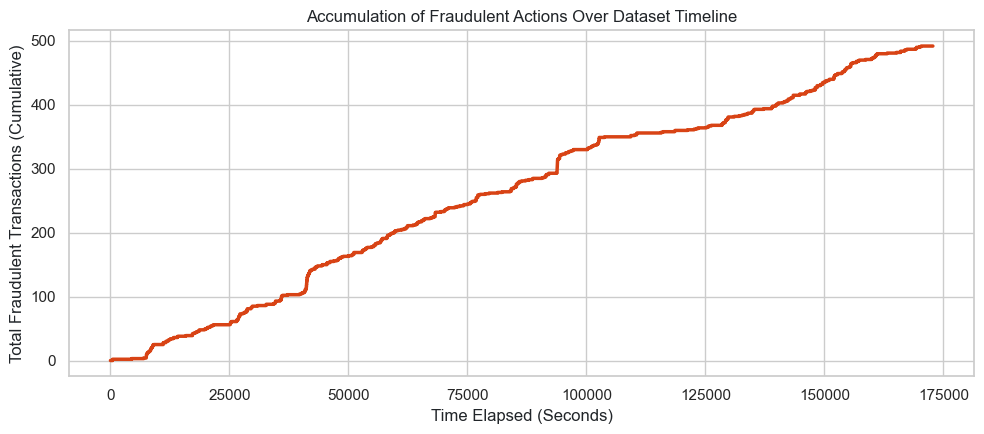

In [8]:
df_sorted = df.sort_values('Time')
df_sorted['Cumulative_Fraud'] = df_sorted['Class'].cumsum()

plt.figure(figsize=(10, 4.5))
plt.plot(df_sorted['Time'], df_sorted['Cumulative_Fraud'], color='#D84315', linewidth=2.5)
plt.xlabel('Time Elapsed (Seconds)')
plt.ylabel('Total Fraudulent Transactions (Cumulative)')
plt.title('Accumulation of Fraudulent Actions Over Dataset Timeline')
plt.tight_layout()
plt.show()

### 2. Bar Charts (Vertical & Horizontal): Fraud Count by hour of day

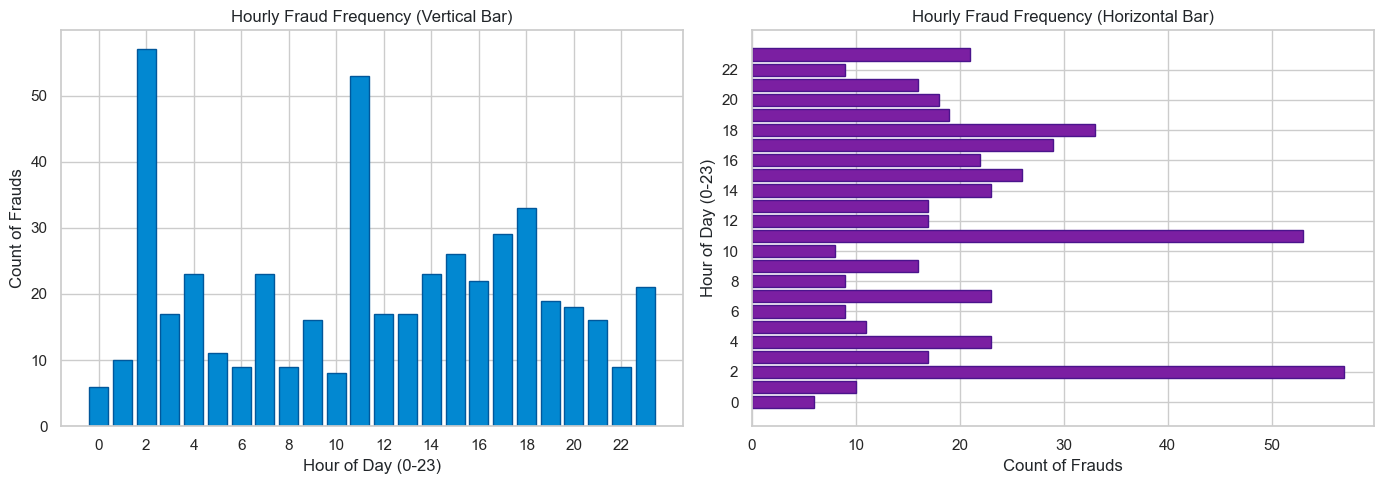

In [9]:
hourly_fraud = df.groupby('Hour')['Class'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vertical Bar Chart
axes[0].bar(hourly_fraud.index, hourly_fraud.values, color='#0288D1', edgecolor='#01579B')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Count of Frauds')
axes[0].set_title('Hourly Fraud Frequency (Vertical Bar)')
axes[0].set_xticks(range(0, 24, 2))

# Horizontal Bar Chart
axes[1].barh(hourly_fraud.index, hourly_fraud.values, color='#7B1FA2', edgecolor='#4A148C')
axes[1].set_ylabel('Hour of Day (0-23)')
axes[1].set_xlabel('Count of Frauds')
axes[1].set_title('Hourly Fraud Frequency (Horizontal Bar)')
axes[1].set_yticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

### 3. Histogram: Amount Log-scale distribution comparison

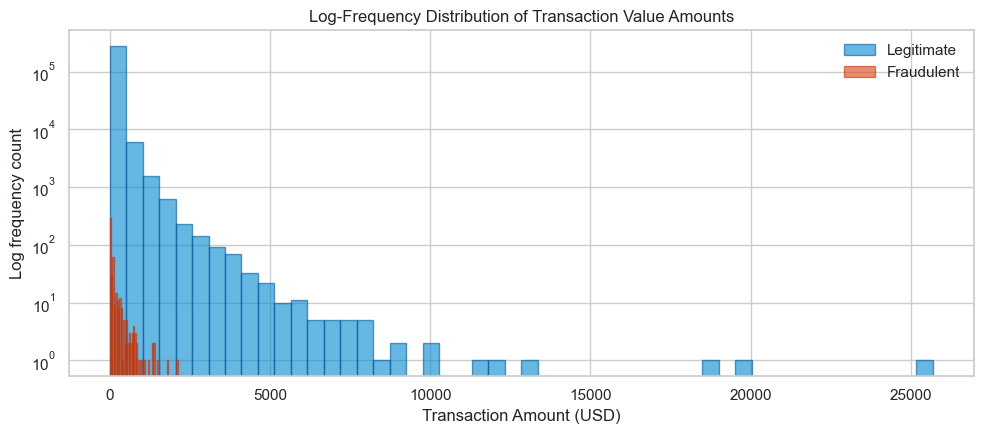

In [10]:
plt.figure(figsize=(10, 4.5))
plt.hist(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.6, label='Legitimate', color='#0288D1', log=True, edgecolor='#01579B')
plt.hist(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.6, label='Fraudulent', color='#D84315', log=True, edgecolor='#BF360C')
plt.xlabel('Transaction Amount (USD)')
plt.ylabel('Log frequency count')
plt.title('Log-Frequency Distribution of Transaction Value Amounts')
plt.legend()
plt.tight_layout()
plt.show()

### 4. Scatter Plot: Transaction Amount vs. Time

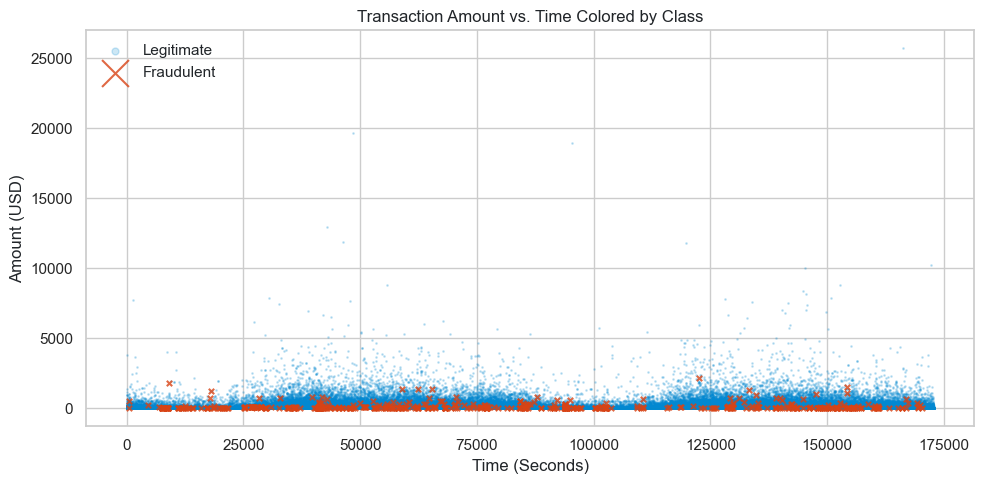

In [11]:
plt.figure(figsize=(10, 5))
plt.scatter(df[df['Class'] == 0]['Time'], df[df['Class'] == 0]['Amount'], alpha=0.2, label='Legitimate', color='#0288D1', s=1)
plt.scatter(df[df['Class'] == 1]['Time'], df[df['Class'] == 1]['Amount'], alpha=0.8, label='Fraudulent', color='#D84315', s=15, marker='x')
plt.xlabel('Time (Seconds)')
plt.ylabel('Amount (USD)')
plt.title('Transaction Amount vs. Time Colored by Class')
plt.legend(markerscale=5)
plt.tight_layout()
plt.show()

### 5. Pie Chart: Proportions of Legitimate vs. Fraudulent Transactions

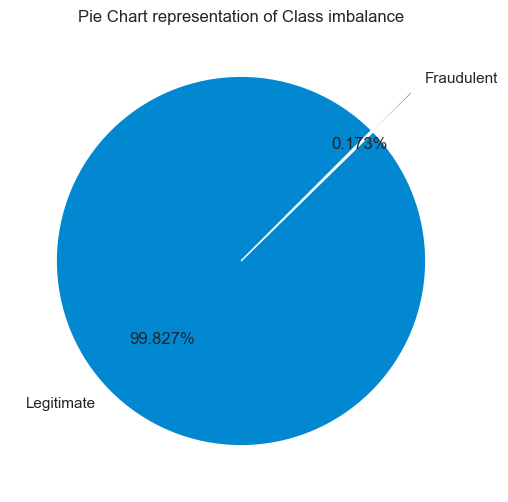

In [12]:
plt.figure(figsize=(6, 6))
plt.pie(df['Class'].value_counts(), labels=['Legitimate', 'Fraudulent'], autopct='%1.3f%%', 
        explode=[0, 0.3], colors=['#0288D1', '#D84315'], startangle=45)
plt.title('Pie Chart representation of Class imbalance')
plt.show()

### 6. Box Plot: Log Scale Range comparison

C:\Users\user\AppData\Local\Temp\ipykernel_217468\549637337.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


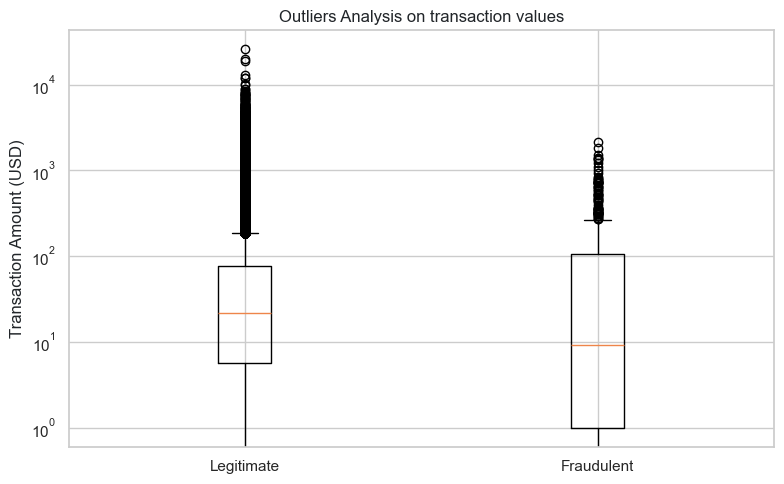

In [13]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [df[df['Class'] == 0]['Amount'], df[df['Class'] == 1]['Amount']],
    labels=['Legitimate', 'Fraudulent']
)
plt.ylabel('Transaction Amount (USD)')
plt.yscale('log')
plt.title('Outliers Analysis on transaction values')
plt.tight_layout()
plt.show()

## Part 3: Visual EDA using Seaborn
We recreate visual distributions and relationships using the advanced styling features of Seaborn.

### 1. Countplot: Visualizing Class Balance

C:\Users\user\AppData\Local\Temp\ipykernel_217468\755686905.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set2')


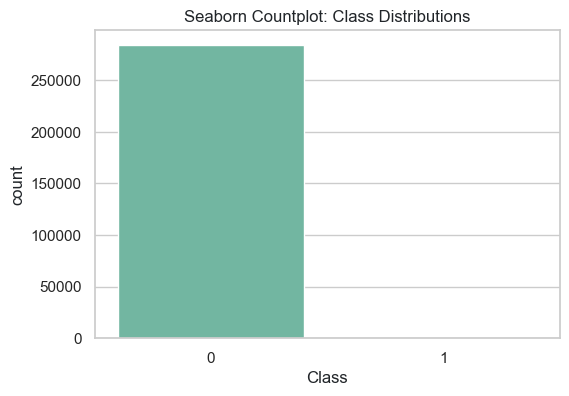

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Seaborn Countplot: Class Distributions')
plt.show()

### 2. Barplot: Average Transaction Amount by Hour of day

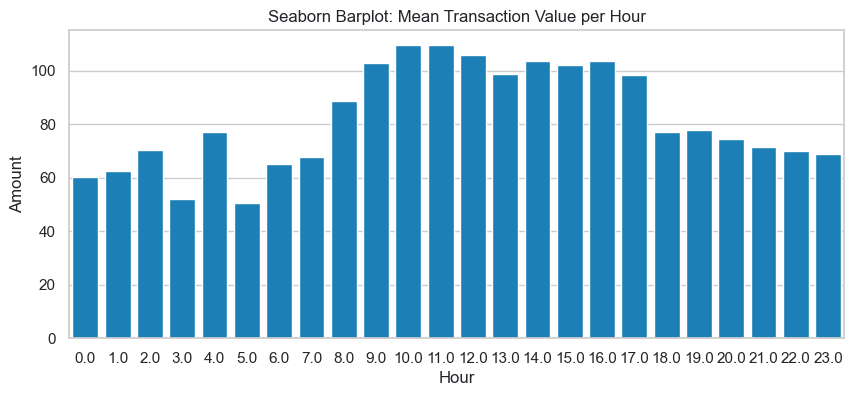

In [15]:
plt.figure(figsize=(10, 4))
sns.barplot(x='Hour', y='Amount', data=df, errorbar=None, color='#0288D1')
plt.title('Seaborn Barplot: Mean Transaction Value per Hour')
plt.show()

### 3. Histplot: Transaction Value distributions (Log Scale)

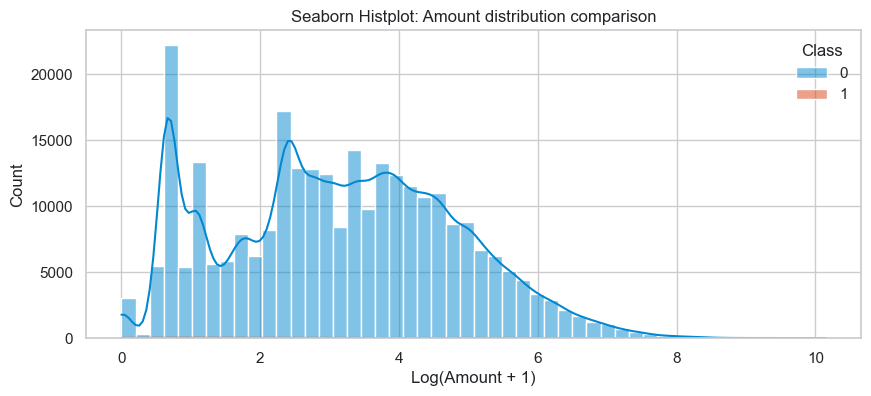

In [16]:
plt.figure(figsize=(10, 4))
sns.histplot(x=np.log1p(df['Amount']), hue=df['Class'], bins=50, kde=True, common_norm=False, palette=['#0288D1', '#D84315'])
plt.xlabel('Log(Amount + 1)')
plt.title('Seaborn Histplot: Amount distribution comparison')
plt.show()

### 4. KDE Plot: Smoothed Transaction Densities Over Time

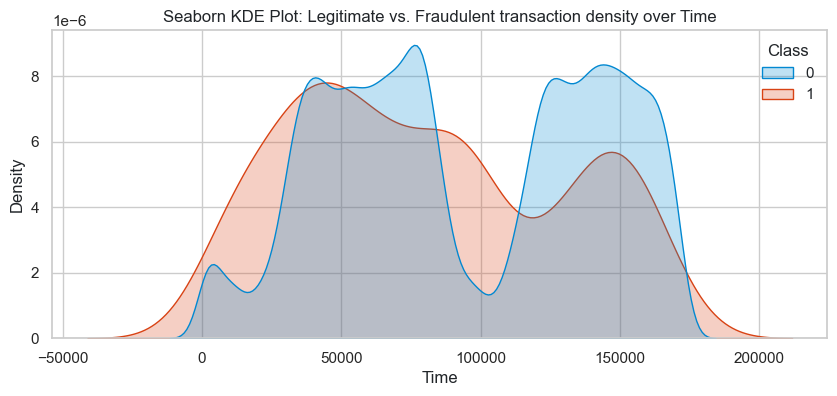

In [17]:
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df, x='Time', hue='Class', fill=True, common_norm=False, palette=['#0288D1', '#D84315'])
plt.title('Seaborn KDE Plot: Legitimate vs. Fraudulent transaction density over Time')
plt.show()

### 5. Boxplot & Violinplot of highly correlated PCA Features
Let's visualize the variations of PCA components V17 and V14 between classes.

C:\Users\user\AppData\Local\Temp\ipykernel_217468\2601620771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='V17', data=df, ax=axes[0], palette=['#0288D1', '#D84315'])


C:\Users\user\AppData\Local\Temp\ipykernel_217468\2601620771.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Class', y='V14', data=df, ax=axes[1], palette=['#0288D1', '#D84315'])


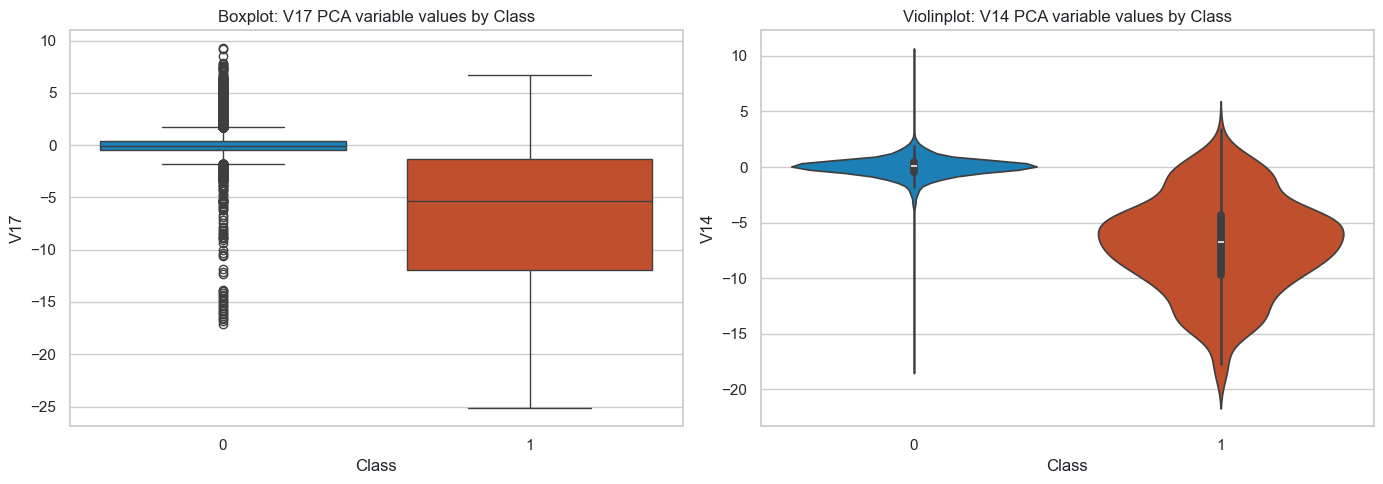

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot of V17
sns.boxplot(x='Class', y='V17', data=df, ax=axes[0], palette=['#0288D1', '#D84315'])
axes[0].set_title('Boxplot: V17 PCA variable values by Class')

# Violinplot of V14
sns.violinplot(x='Class', y='V14', data=df, ax=axes[1], palette=['#0288D1', '#D84315'])
axes[1].set_title('Violinplot: V14 PCA variable values by Class')

plt.tight_layout()
plt.show()

### 6. Stripplot: Transaction Values distribution scatter

C:\Users\user\AppData\Local\Temp\ipykernel_217468\2964772046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Class', y=np.log1p(df['Amount']), data=df, jitter=0.3, alpha=0.1, size=2, palette=['#0288D1', '#D84315'])


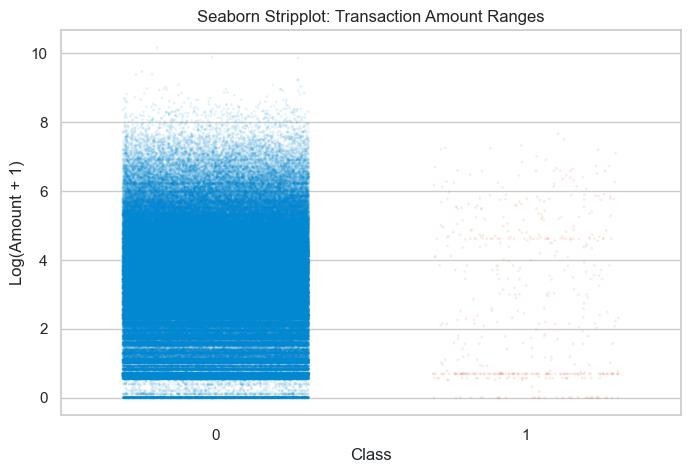

In [19]:
plt.figure(figsize=(8, 5))
sns.stripplot(x='Class', y=np.log1p(df['Amount']), data=df, jitter=0.3, alpha=0.1, size=2, palette=['#0288D1', '#D84315'])
plt.ylabel('Log(Amount + 1)')
plt.title('Seaborn Stripplot: Transaction Amount Ranges')
plt.show()

### 7. Jointplot: Visualizing correlation between features V17 and V12
Jointplots allow visualizing marginal densities alongside scatter associations. We draw a sample of 20,000 transactions for plotting speed.

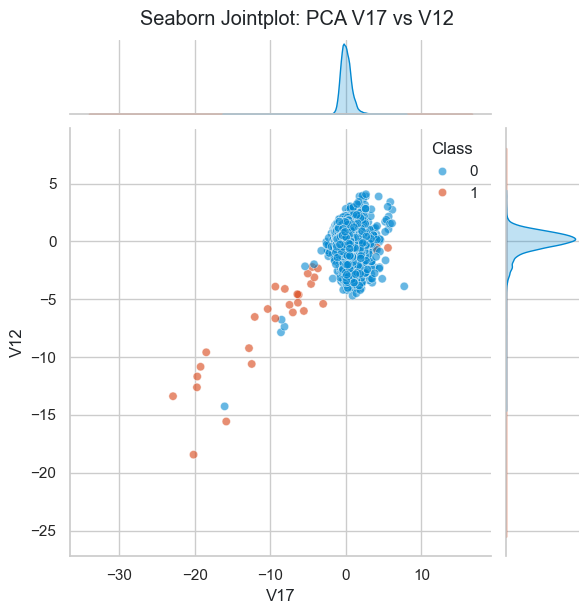

In [20]:
df_sample = df.sample(20000, random_state=42)
grid = sns.jointplot(x='V17', y='V12', data=df_sample, hue='Class', palette=['#0288D1', '#D84315'], alpha=0.6, height=6)
grid.fig.suptitle('Seaborn Jointplot: PCA V17 vs V12', y=1.02)
plt.show()

### 8. Pairplot: Multi-variable interactions
Let's review the pairwise relationships across highly correlated components (V17, V14, V12) and Amount. We draw a sample of 5,000 for presentation speed.

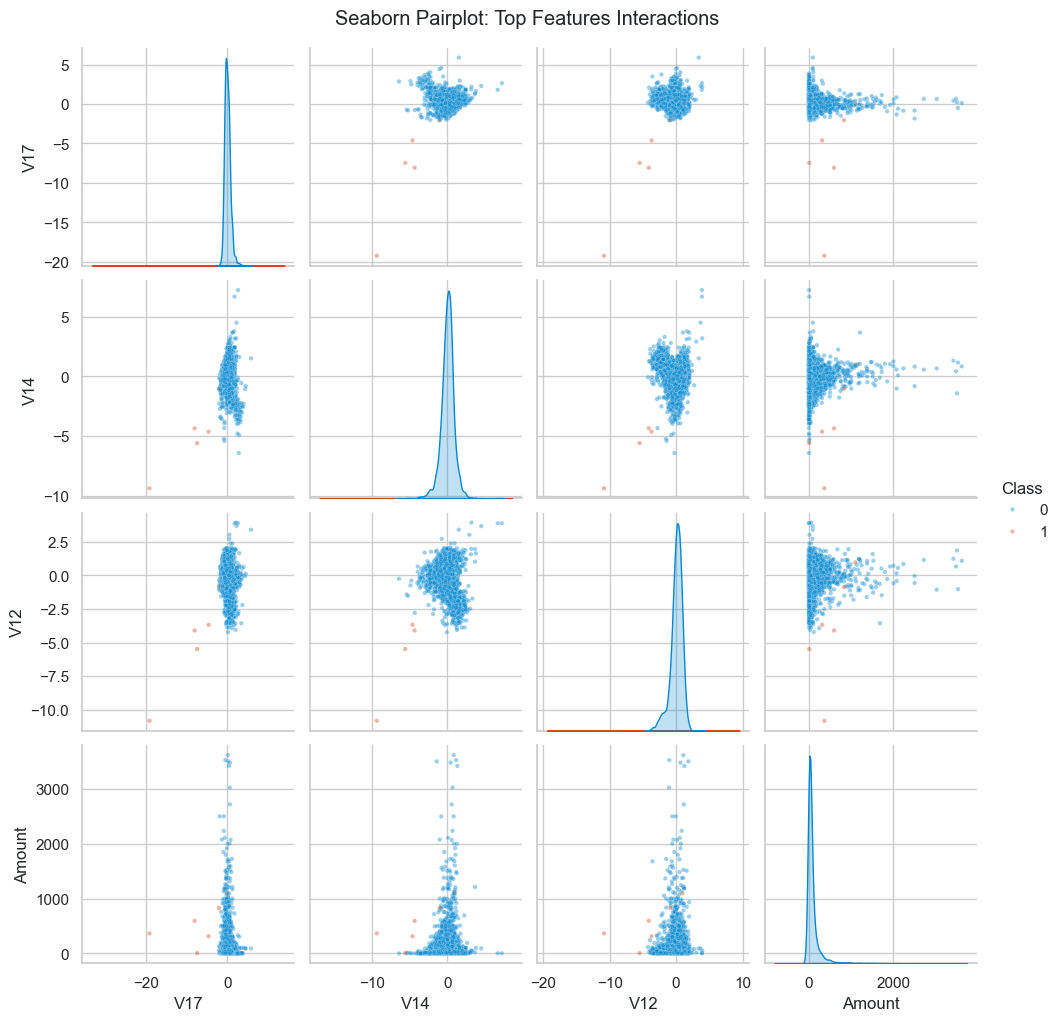

In [21]:
features_to_plot = ['V17', 'V14', 'V12', 'Amount', 'Class']
df_pair = df[features_to_plot].sample(5000, random_state=42)
sns.pairplot(df_pair, hue='Class', palette=['#0288D1', '#D84315'], diag_kind='kde', plot_kws={'alpha':0.4, 's':10})
plt.suptitle('Seaborn Pairplot: Top Features Interactions', y=1.02)
plt.show()

## Part 4: Data Leakage Protection & Train-Test Splits
To prevent **Data Leakage**, we must partition data into training and test sets *before* performing scaling. 

We drop structural query helper columns (e.g. `Hour`), divide classes evenly using stratification, and scale features.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into features and target
X = df.drop(columns=['Class', 'Hour'])
y = df['Class']

# Stratified Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize Scaler
scaler = StandardScaler()

# Fit only on training set and transform both
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("Training Set Features Shape:", X_train_scaled.shape)
print("Testing Set Features Shape:", X_test_scaled.shape)

Training Set Features Shape: (227845, 30)
Testing Set Features Shape: (56962, 30)


## Part 5: Class Imbalance Mitigation
We apply **SMOTE** strictly to the training split only to avoid testing leaks. We compare this with algorithmic weights.

In [23]:
from imblearn.over_sampling import SMOTE

print("Original training target distribution:")
print(y_train.value_counts())

# Apply SMOTE strictly to the training split only!
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("\nResampled training target distribution (SMOTE):")
print(y_train_res.value_counts())

Original training target distribution:
Class
0    227451
1       394
Name: count, dtype: int64



Resampled training target distribution (SMOTE):
Class
0    227451
1    227451
Name: count, dtype: int64


## Part 6: Model Building & Comparison
We train three separate configurations of **Logistic Regression** (Baseline, Class-Weighted, and SMOTE-oversampled) to compare metrics side-by-side. We then evaluate ensemble classifiers (**Random Forest** and **XGBoost**).

In [24]:
from sklearn.linear_model import LogisticRegression

# 1. Baseline Model
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

# 2. Class Weighted Model
lr_weighted = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_weighted.fit(X_train_scaled, y_train)

# 3. SMOTE Model
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_res, y_train_res)

print("Baseline, Weighted, and SMOTE Logistic Regressions trained successfully!")

Baseline, Weighted, and SMOTE Logistic Regressions trained successfully!


## Part 7: Evaluation & Metrics Trade-off
Let's write a utility function to evaluate each model. We prioritize **Recall** (catching all actual frauds) over **Precision** (avoiding false alarms) since missing a fraud case is extremely costly.

=== Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9559



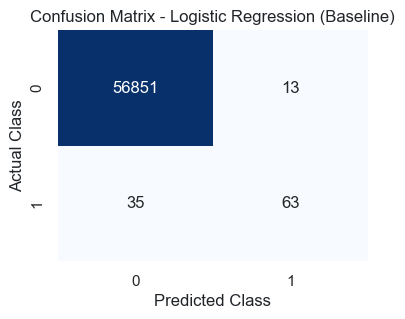

=== Logistic Regression (Class Weighted) ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC Score: 0.9722



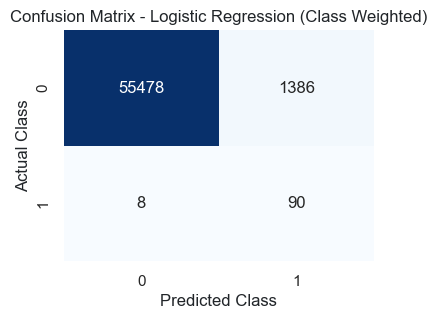

=== Logistic Regression (SMOTE) ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9699



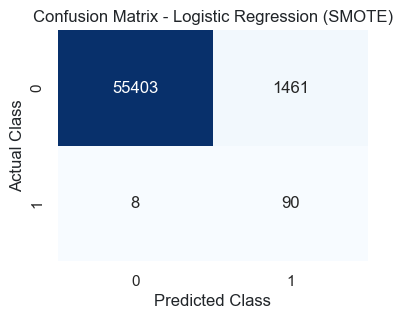

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"=== {title} ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}\n")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

evaluate_model(lr_baseline, X_test_scaled, y_test, "Logistic Regression (Baseline)")
evaluate_model(lr_weighted, X_test_scaled, y_test, "Logistic Regression (Class Weighted)")
evaluate_model(lr_smote, X_test_scaled, y_test, "Logistic Regression (SMOTE)")

### Ensembles Training: Random Forest & XGBoost

=== Random Forest (Weighted) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9529



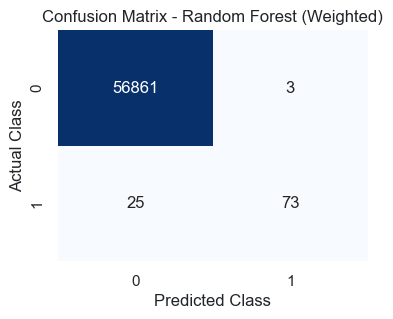

=== XGBoost (Weighted) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9726



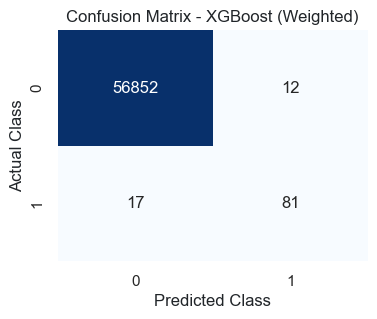

In [26]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest with balanced weights
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# XGBoost with scale_pos_weight
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
xgb.fit(X_train_scaled, y_train)

evaluate_model(rf, X_test_scaled, y_test, "Random Forest (Weighted)")
evaluate_model(xgb, X_test_scaled, y_test, "XGBoost (Weighted)")

## Part 8: Hyperparameter Tuning
We will tune the parameters of our XGBoost model using `RandomizedSearchCV`, scoring specifically on `'f1'` to balance precision and recall.

Best Hyperparameters Found: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2}
=== Tuned XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.85      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9701



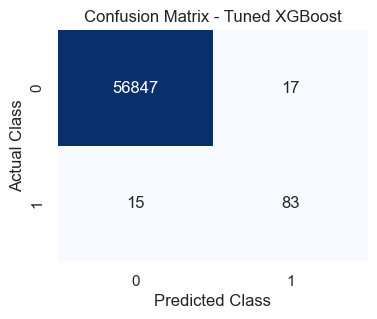

In [27]:
from sklearn.model_selection import RandomizedSearchCV

# Parameters distribution grid
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=8,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_scaled, y_train)
best_xgb = random_search.best_estimator_

print("Best Hyperparameters Found:", random_search.best_params_)
evaluate_model(best_xgb, X_test_scaled, y_test, "Tuned XGBoost")

## Part 9: Serialization & Export
Finally, we serialize and save both our trained scaler and the tuned XGBoost classifier to disk so they can be loaded and deployed in production environments.

In [28]:
import joblib

# Export files
joblib.dump(best_xgb, 'best_fraud_model.pkl')
joblib.dump(scaler, 'fraud_scaler.pkl')
print("Model and Scaler successfully saved to disk!")

Model and Scaler successfully saved to disk!
